In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("feature_engineered_crop_data.csv")

df.head()

,Area,Item,Year,Crop_Yield,Rainfall,Pesticides,Temperature,Rainfall_Category,Temperature_Band,Pesticide_Category,Rainfall_Temp_Index,Pesticide_Efficiency,Log_Pesticides
0,Albania,Maize,1990,36613.0,1485.0,121.0,16.37,Moderate,Cool,Low,24309.45,300.106557,4.804021
1,Albania,Potatoes,1990,66667.0,1485.0,121.0,16.37,Moderate,Cool,Low,24309.45,546.450820,4.804021
2,Albania,"Rice, paddy",1990,23333.0,1485.0,121.0,16.37,Moderate,Cool,Low,24309.45,191.254098,4.804021
3,Albania,Sorghum,1990,12500.0,1485.0,121.0,16.37,Moderate,Cool,Low,24309.45,102.459016,4.804021
4,Albania,Soybeans,1990,7000.0,1485.0,121.0,16.37,Moderate,Cool,Low,24309.45,57.377049,4.804021


In [3]:
X = df.drop(columns=["Crop_Yield"])

y = df["Crop_Yield"]

In [4]:
numerical_features = [

    "Year",

    "Rainfall",

    "Pesticides",

    "Temperature",

    "Rainfall_Temp_Index",

    "Log_Pesticides"

]

categorical_features = [

    "Area",

    "Item",

    "Rainfall_Category",

    "Temperature_Band",

    "Pesticide_Category"

]

In [5]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            numerical_features

        ),

        (

            "cat",

            OneHotEncoder(

                handle_unknown="ignore"

            ),

            categorical_features

        )

    ]

)

In [6]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [7]:
models = {

    "Linear Regression":LinearRegression(),

    "Ridge Regression":Ridge(),

    "Lasso Regression":Lasso(),

    "Decision Tree":DecisionTreeRegressor(

        max_depth=10,

        random_state=42

    ),

    "Random Forest":RandomForestRegressor(

        n_estimators=50,

        random_state=42,

        n_jobs=-1

    ),

    "Gradient Boosting":GradientBoostingRegressor(

        n_estimators=50,

        random_state=42

    )

}

In [8]:
results = []

best_model = None

best_score = -999

kfold = KFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

for name, model in models.items():

    print("="*60)

    print(f"Training {name}")

    pipeline = Pipeline([

        ("preprocessor",preprocessor),

        ("model",model)

    ])

    pipeline.fit(

        X_train,

        y_train

    )

    prediction = pipeline.predict(

        X_test

    )

    mae = mean_absolute_error(

        y_test,

        prediction

    )

    rmse = np.sqrt(

        mean_squared_error(

            y_test,

            prediction

        )

    )

    r2 = r2_score(

        y_test,

        prediction

    )

    cv_score = cross_val_score(

        pipeline,

        X_train,

        y_train,

        cv=kfold,

        scoring="r2",

        n_jobs=-1

    ).mean()

    results.append([

        name,

        mae,

        rmse,

        r2,

        cv_score

    ])

    print(f"R² : {r2:.4f}")

    print(f"CV : {cv_score:.4f}")

    if r2 > best_score:

        best_score = r2

        best_model = pipeline

Training Linear Regression
R² : 0.8014
CV : 0.7982
Training Ridge Regression
R² : 0.8013
CV : 0.7982
Training Lasso Regression
R² : 0.8013
CV : 0.7982
Training Decision Tree
R² : 0.9277
CV : 0.9272
Training Random Forest
R² : 0.9847
CV : 0.9835
Training Gradient Boosting
R² : 0.8375
CV : 0.8395


In [9]:
results = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2",

        "Cross Validation"

    ]

)

results.sort_values(

    "R2",

    ascending=False,

    inplace=True

)

results

,Model,MAE,RMSE,R2,Cross Validation
4,Random Forest,3499.419341,8710.547255,0.984662,0.983493
3,Decision Tree,11711.923044,18914.299074,0.927679,0.927155
5,Gradient Boosting,20299.701464,28353.108225,0.837487,0.839465
0,Linear Regression,22869.831125,31342.922220,0.801407,0.798222
2,Lasso Regression,22861.519206,31349.526745,0.801323,0.798244
1,Ridge Regression,22862.074399,31352.387455,0.801287,0.798216


In [10]:
results.to_csv(

    "model_results.csv",

    index=False

)

In [11]:
joblib.dump(

    best_model,

    "best_model.pkl"

)

print("Best Model Saved Successfully")

Best Model Saved Successfully


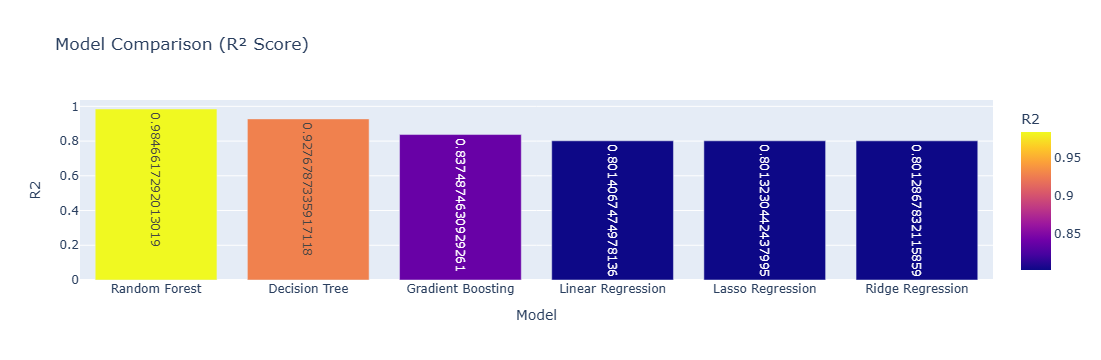

In [12]:
import plotly.express as px

fig = px.bar(

    results,

    x="Model",

    y="R2",

    color="R2",

    text="R2",

    title="Model Comparison (R² Score)"

)

fig.show()

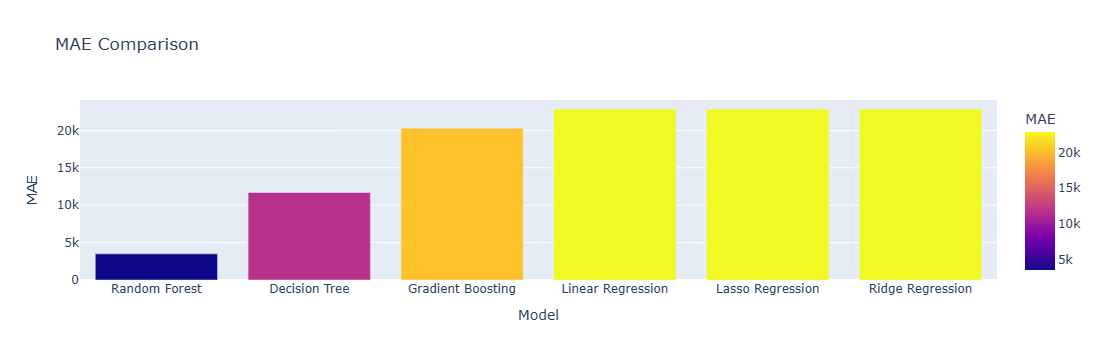

In [13]:
fig = px.bar(

    results,

    x="Model",

    y="MAE",

    color="MAE",

    title="MAE Comparison"

)

fig.show()

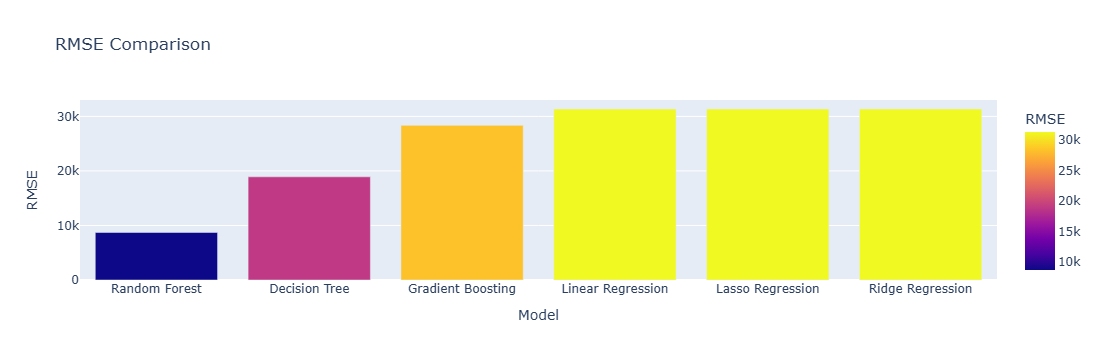

In [14]:
fig = px.bar(

    results,

    x="Model",

    y="RMSE",

    color="RMSE",

    title="RMSE Comparison"

)

fig.show()

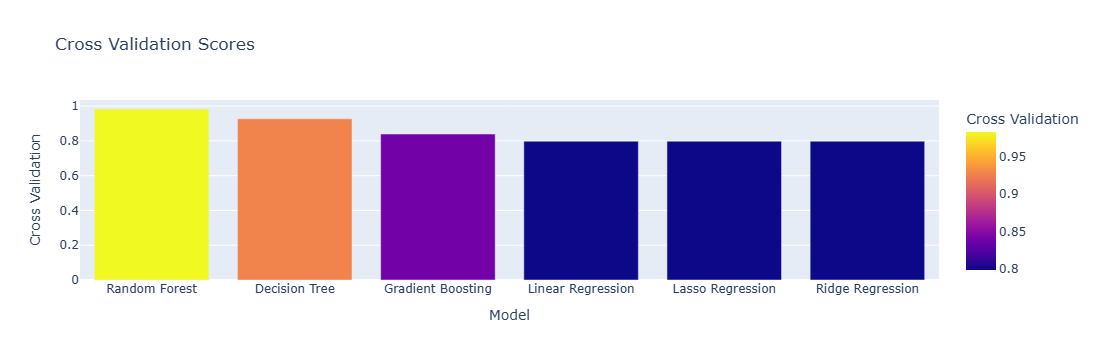

In [15]:
fig = px.bar(

    results,

    x="Model",

    y="Cross Validation",

    color="Cross Validation",

    title="Cross Validation Scores"

)

fig.show()

In [16]:
print("="*70)

print("MODEL TRAINING COMPLETED")

print("="*70)

print()

print("Best Model")

print(best_model)

print()

print(results)

MODEL TRAINING COMPLETED

Best Model
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Rainfall',
                                                   'Pesticides', 'Temperature',
                                                   'Rainfall_Temp_Index',
                                                   'Log_Pesticides']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Area', 'Item',
                                                   'Rainfall_Category',
                                                   'Temperature_Band',
                                                   'Pesticide_Category'])])),
                ('model',
                 RandomForestRegressor(n_estimators=50, n_jobs=-1,
                               

In [17]:
print(df.columns.tolist())

['Area', 'Item', 'Year', 'Crop_Yield', 'Rainfall', 'Pesticides', 'Temperature', 'Rainfall_Category', 'Temperature_Band', 'Pesticide_Category', 'Rainfall_Temp_Index', 'Pesticide_Efficiency', 'Log_Pesticides']
